# Version with water under the prism

# Interferometric Reflectivity Dip : non locality impact check

The objective of this notebook is to evaluate the impact of the non locality on the IRD observable and to do some extra plots.

### Importation of the needed libraries

PyMoosh is a open source, user-friendly library for the optical study of multilayered structures, written in Python. The "my_module" library corresponds to a module which contains home made functions needed for this work.

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft2, fftshift, ifft2
from scipy.integrate import trapezoid
from scipy.special import wofz
import PyMoosh as PM
import my_module as my_mod
from joblib import Parallel, delayed
from tqdm import tqdm
import multiprocessing
from PyMoosh import non_local as NL

font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 18}

plt.rc('font', **font)

SAVE_MODE = True # state variable to set if the plots are saved in separated files
save_formats = ["pdf", "svg"] # list with the formats to use to save plots

# define the number of CPU core to use for multiprocessing
total_cores = multiprocessing.cpu_count()
reserved_cores = 4  # number of CPU core reserved for the system
n_jobs = max(1, total_cores - reserved_cores)

### Observable determination without non locality

One easy envisageable experiment is to perform measurements by varying the incidence angle. The goal is to find an experimentally accessible observable which can unravel the beam narrowing.

The observable measurements will be realised after the second optical system in the real world, but as the effect of the second optical system can be reduced to an enlargement of the x and y scales, it is enough to perform our search just after the reflection (to be coherent on the effect visualisation each axis is inverted because the second optical system magnification is negative). In this notebook the first optical system is also not simulated completely, his magnification is directly considered on the waists before the reflection in order to have an observable search which corresponds to the system determined (it is also possible to consider the ideal theoretical waist in place depending on your goal).

In [2]:
# initialisation of the needed parameters, other than the incidence,
n1 = 1 # air refractive index
n2 = 1.515  # glass refractive index
wavelength = 632.8
k0 = 2 * np.pi / wavelength
N = 100
alpha0 = 0
beta0 = 0
x0 = 0
y0 = 0
w = 5690*8.118 # the waist before reflection corresponding to the experimental setup defined
# w = 46089 # the optimal waist before reflection
wx = w
wy = w
d = 400000

# the x and y-axes considered
x = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
y = np.linspace(-N, N, 2 * N + 1) * (d / 2) / N
# grids of the axes
X, Y = np.meshgrid(x, y)

# definition of the spectral grid
pask = 2 * np.pi / d  # definition of the spectral step
a = np.arange(-N, N + 1) * pask  # alpha (kx) range in nm-1
b = a  # beta (ky) range in nm-1
A, B = np.meshgrid(a, b)  # alpha and beta grid

# definition of the structure on which the reflection is done
# get the material from refractiveindex database (RII) when possible
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au = PM.Material(["main", "Au", "Rakic-BB"], specialType="RII")
h_Au = 47
mat = ["BK7",Cr,Au,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure = PM.Structure(mat, stack, thickness, verbose=False)

Determination of the local minimum intensity (and neighbors) indices. In order to know where to look for the observables.

In [3]:
kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)
inc = 73.38
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = PM.coefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection
# determination of the light intensity (reverted to correspond ta take into account the sign of the second optical system magnification)
I = (np.abs(U1i)**2)[::-1, ::-1]
I_rel = I/np.max(I)
index_max_x, index_max_y = np.unravel_index(np.argmax(I), I_rel.shape) # line index (axis 0) and column index (axis 1) corresponding to the maximum intensity 
# search of the indices corresponding to the local minimum of intensities to build observables (the search is done from the max position towards the effect direction)
# first observables : light intensity around local minimum (on the xmax line)
# searching of the local minimum indices
index_loc_min_y=0
if(index_max_y<N):
    for i in range(index_max_y,2*N+1,1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
else:
    for i in range(index_max_y,0,-1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
# second observables : light intensity projected on x (sum on the y) around local minimum
I_proj_x = np.sum(I, axis=0)
I_proj_x_rel = I_proj_x / np.max(I_proj_x)
ind_proj_max = np.argmax(I_proj_x)
ind_proj_loc_min = 0
if(ind_proj_max<N):
    for i in range(ind_proj_max,2*N+1,1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break
else:
    for i in range(ind_proj_max,0,-1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break



Local min of light intensity on the x axis with max found at ((np.int64(100), 79)) with a relative intensity of 0.00011234967959487303
Local min of light intensity projected on x found at (79) with a relative intensity of 0.00011189468996970868


Determination of the enlargements and possible observables as function of the incidence angle.

In [4]:
# initialisation
# inc_range = np.linspace(71, 75, int((75 - 71) / 0.01) + 1)  # range of incidence considered
inc_range = np.linspace(50, 85, int((85 - 50) / 0.01) + 1)  # range of incidence considered
ELx = []
num_neighbors = 20
I_REL_min = np.empty((0, num_neighbors + 1))
I_PROJ_REL_min = np.empty((0, num_neighbors + 1))

kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave

def process_one_inc(inc):
    # reflection
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave
    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = PM.coefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)  # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)  # spectral beam before reflection
    U1ki = cr * U1k  # spectral beam after reflection
    U1i = ifft2(U1ki)  # spatial beam after reflection

    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    # determination of the shift
    decx = bxU1i - bxU1
    decy = byU1i - byU1

    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    # save of the x enlargement
    # determination of the light intensity (reverted to take into account the sign of the second optical system magnification)
    I = (np.abs(U1i)**2)[::-1, ::-1]
    I_rel = I / np.max(I)

    # observables = relative intensities at local minimum and neighbors towards the max
    # save of the first observables : light intensity around local minimum (on the xmax line at 44.1)
    if index_max_y < N:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y - num_neighbors - 1:-1]
    else:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y + num_neighbors + 1:1]

    # save of the second observables : light intensity projected on x (sum on the y) around local minimum
    I_proj_x = np.sum(I, axis=0)
    I_proj_x_rel = I_proj_x / np.max(I_proj_x)

    if ind_proj_max < N:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min - num_neighbors - 1:-1]
    else:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min + num_neighbors + 1:1]

    return elarrelatx, I_rel_min_line, I_proj_rel_min_line

results = Parallel(n_jobs=n_jobs)(delayed(process_one_inc)(inc) for inc in tqdm(inc_range, desc="Scan of all the incidences"))

for elx, Irel, Iproj in results:
    ELx.append(elx)
    I_REL_min = np.append(I_REL_min, [Irel], axis=0)
    I_PROJ_REL_min = np.append(I_PROJ_REL_min, [Iproj], axis=0)


Scan of all the incidences: 100%|██████████| 3501/3501 [14:14<00:00,  4.10it/s]


The best relative intensity observable is for Neighbor 14 with max - min = 0.5024550757486858.
The best projected relative intensity observable is for Neighbor 14 with max - min = 0.5024462324756299.


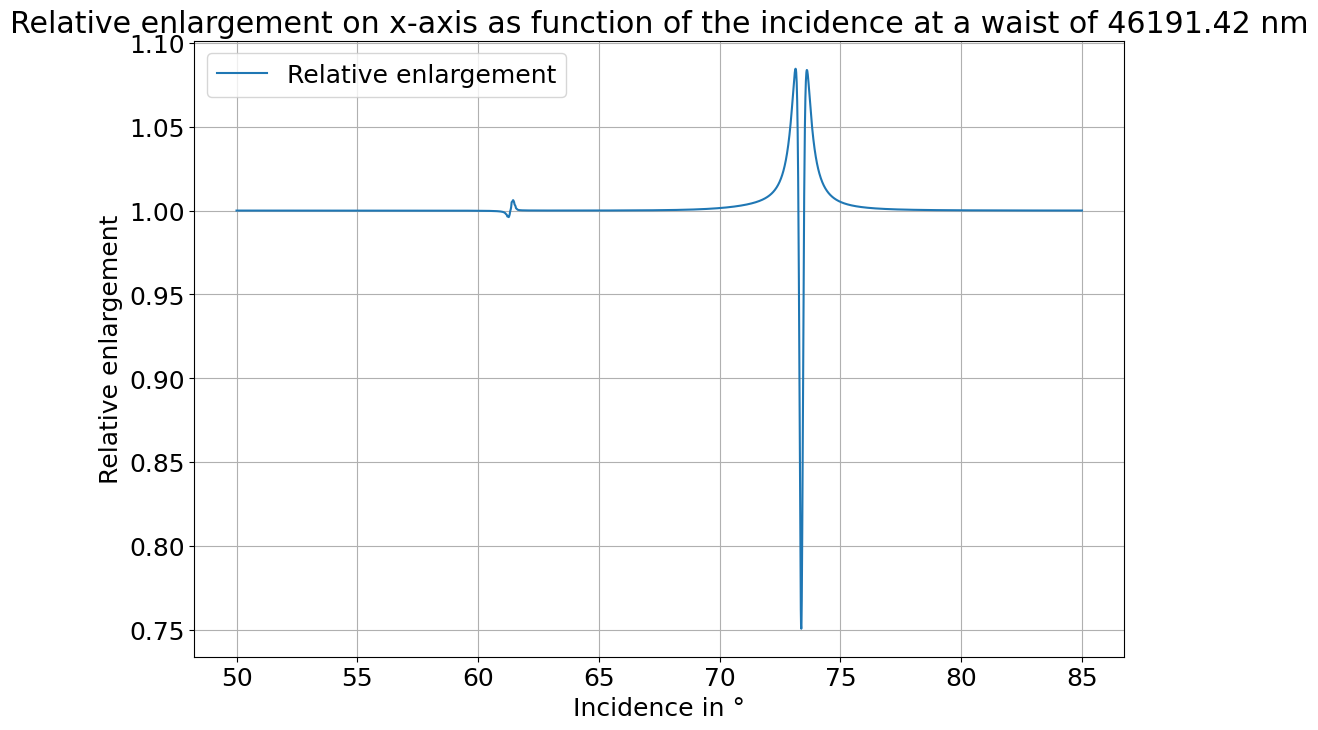

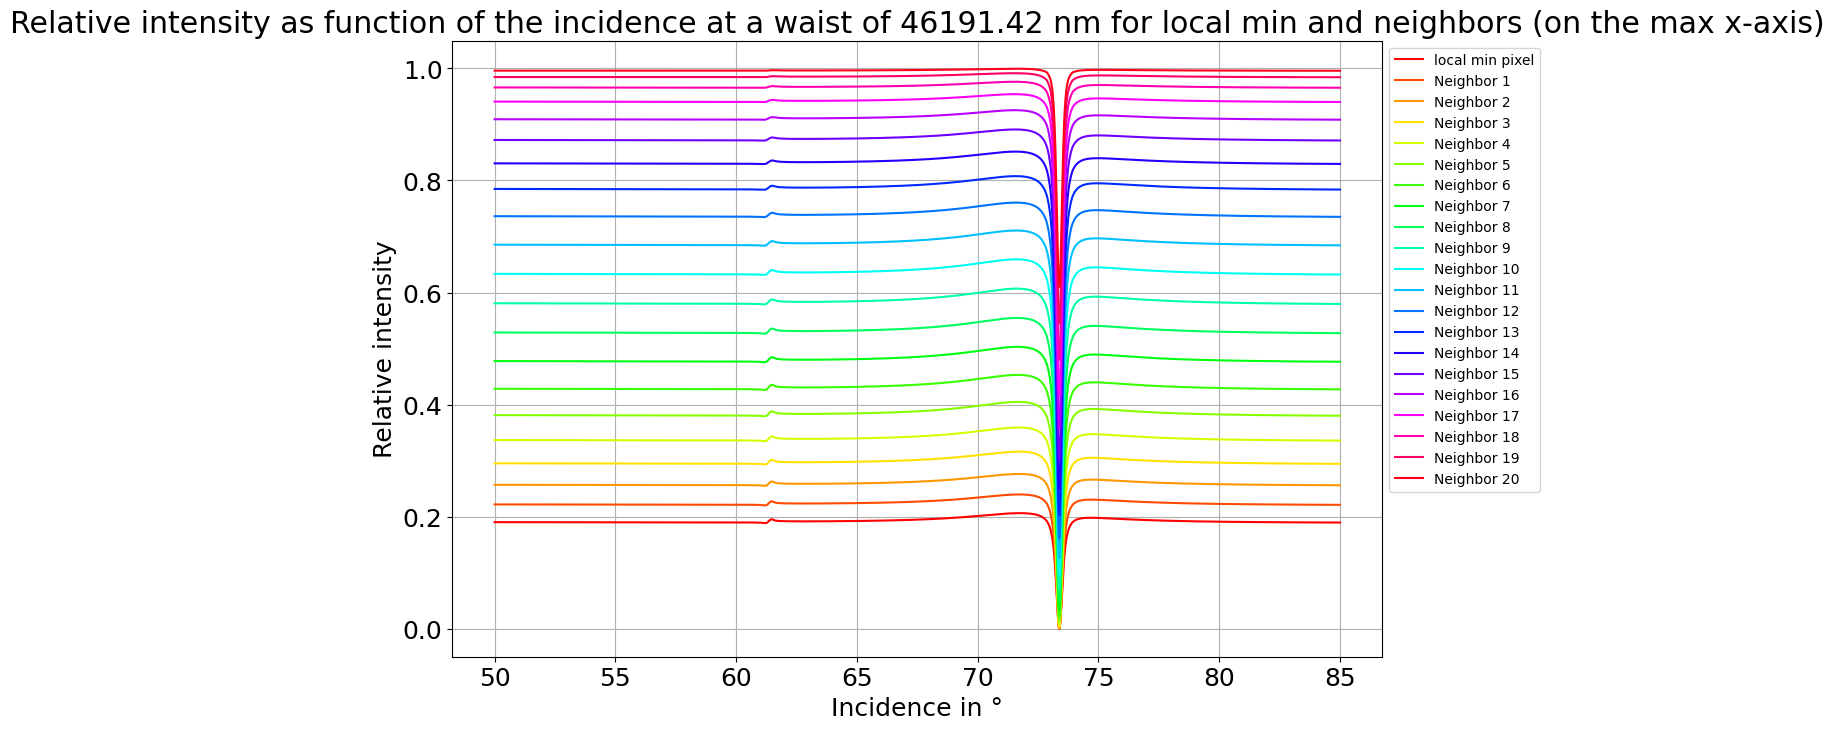

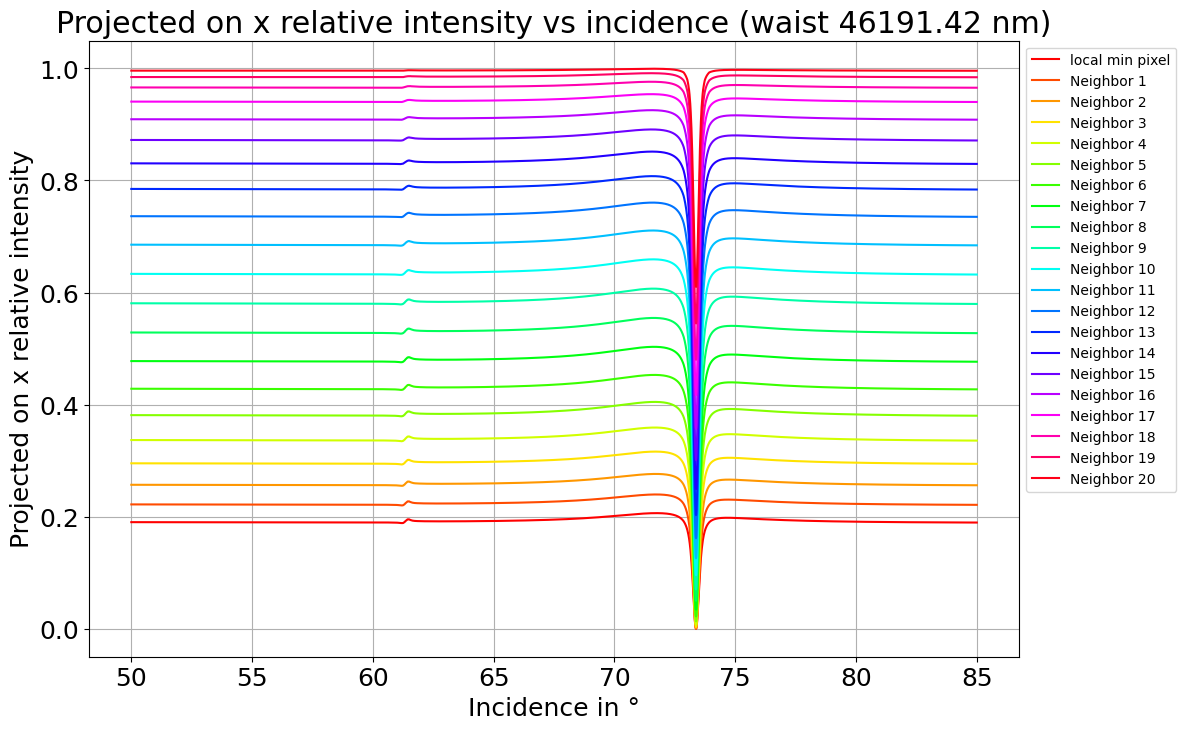

In [5]:
plt.figure(figsize=(12,8))
plt.plot(inc_range, np.array(ELx), label="Relative enlargement")
plt.title(f"Relative enlargement on x-axis as function of the incidence at a waist of {w} nm")
plt.xlabel("Incidence in °")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/x_rel_enlargement.{file_ext}", bbox_inches="tight")

# where to look for the best neighbors (we are interested in  the dip area)
inc_dip_low_lim = 73.1
inc_dip_high_lim = 73.7

line_label=[f"Neighbor {i}" for i in range(0,num_neighbors+1)]
line_label[0]="local min pixel"
plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_REL_min[:,i], color=colors(i), label=line_label[i])
plt.title(f"Relative intensity as function of the incidence at a waist of {w} nm for local min and neighbors (on the max x-axis)")
plt.xlabel("Incidence in °")
plt.ylabel("Relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/rel_intensity_around_local_min.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index=np.argmax(max_min_dif)
print(f"The best relative intensity observable is for {line_label[best_index]} with max - min = {max_min_dif[best_index]}.")

plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_PROJ_REL_min[:,i], color=colors(i), label=line_label[i])
plt.title(f"Projected on x relative intensity vs incidence (waist {w} nm)")
plt.xlabel("Incidence in °")
plt.ylabel("Projected on x relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/projected_rel_intensity_around_local_min.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_PROJ_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_PROJ_REL_min[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index=np.argmax(max_min_dif)
print(f"The best projected relative intensity observable is for {line_label[best_index]} with max - min = {max_min_dif[best_index]}.")


In [6]:
num_best_neighbor = best_index

### Observable determination non locality

In [9]:
# definition of the structure on which the reflection is done with NL
# get the material from refractiveindex database (RII) when possible
# NL_Au function
planck_eVm = 1.2398419843320028e-06
electron_C = 1.602176634e-19
hbar_Js = 1.054571817e-34
rad_per_eV = electron_C / hbar_Js
f0 = 0.770
Gamma0 = 0.050
omega_p = 9.03
f = np.array([0.054, 0.050, 0.312, 0.719, 1.648])
Gamma = np.array([0.074, 0.035, 0.083, 0.125, 0.179])
omega = np.array([0.218, 2.885, 4.069, 6.137, 27.97])
sigma = np.array([0.742, 0.349, 0.830, 1.246, 1.795])
# above are in eV
vFermi_mps = 1.39e6
hyd_factor = 3 / 5


def calc_gold_nl_param(wavelength):
    """
    non local gold parameters from empirical value
    """
    wav_ev = planck_eVm / (wavelength * 1e-9)
    chi_f = -(omega_p**2) * f0 / (wav_ev * (wav_ev + 1j * Gamma0))
    a = np.sqrt(wav_ev * (wav_ev + 1j * Gamma))
    x = (a - omega) / (np.sqrt(2) * sigma)
    y = (a + omega) / (np.sqrt(2) * sigma)
    denominator = 2 * np.sqrt(2) * a * sigma
    term_sum = ((1j * np.sqrt(np.pi) * f * omega_p**2) / denominator * (wofz(x) + wofz(y)))
    chi_b = np.sum(term_sum)
    beta2_mps_sq = hyd_factor * vFermi_mps**2
    beta2_nm_sq = beta2_mps_sq * 1e18
    omega_p_rad_s = omega_p * rad_per_eV
    return beta2_nm_sq, chi_b, chi_f, omega_p_rad_s

def calc_gold_nl_param_w_2nd_viscosity(wavelength):
    """
    non local gold parameters from empirical value
    """
    wav_ev = planck_eVm / (wavelength * 1e-9)
    chi_f = -(omega_p**2) * f0 / (wav_ev * (wav_ev + 1j * Gamma0))
    a = np.sqrt(wav_ev * (wav_ev + 1j * Gamma))
    x = (a - omega) / (np.sqrt(2) * sigma)
    y = (a + omega) / (np.sqrt(2) * sigma)
    denominator = 2 * np.sqrt(2) * a * sigma
    term_sum = ((1j * np.sqrt(np.pi) * f * omega_p**2) / denominator * (wofz(x) + wofz(y)))
    chi_b = np.sum(term_sum)
    beta2_mps_sq = hyd_factor * vFermi_mps**2-1j*(2*np.pi*299792458/(wavelength*1e-9))*8e-4
    beta2_nm_sq = beta2_mps_sq * 1e18
    omega_p_rad_s = omega_p * rad_per_eV
    return beta2_nm_sq, chi_b, chi_f, omega_p_rad_s

Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au_NL = NL.NLMaterial(calc_gold_nl_param_w_2nd_viscosity)
h_Au = 47
mat = ["BK7",Cr,Au_NL,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure = NL.NLStructure(mat, stack, thickness, verbose=False)

Determination of the local minimum intensity (and neighbors) indices. In order to know where to look for the observables.

In [11]:
inc= 73.21
theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2)/ (n2 * k0))  # array with the incidence angle for all incident plane wave
cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
# determination of the reflection coefficients for each plane wave
for i in range(len(a)):
    for j in range(len(b)):
        r, t, R, T = NL.NLcoefficient(structure, wavelength, theta[i,j], 1)
        cr[i, j] = r
U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0) # spatial beam before reflection
U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1) # spectral beam before reflection
U1ki=cr*U1k # spectral beam after reflection
U1i=ifft2(U1ki) # spatial beam after reflection
# determination of the light intensity (reverted to correspond ta take into account the sign of the second optical system magnification)
I = (np.abs(U1i)**2)[::-1, ::-1]
I_rel = I/np.max(I)
index_max_x, index_max_y = np.unravel_index(np.argmax(I), I_rel.shape) # line index (axis 0) and column index (axis 1) corresponding to the maximum intensity 
# search of the indices corresponding to the local minimum of intensities to build observables (the search is done from the max position towards the effect direction)
# first observables : light intensity around local minimum (on the xmax line)
# searching of the local minimum indices
index_loc_min_y=0
if(index_max_y<N):
    for i in range(index_max_y,2*N+1,1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
else:
    for i in range(index_max_y,0,-1):
        if((I_rel[index_max_x,i-1]>I_rel[index_max_x,i])and(I_rel[index_max_x,i+1]>I_rel[index_max_x,i])):
            print(f"Local min of light intensity on the x axis with max found at ({index_max_x, i}) with a relative intensity of {I_rel[index_max_x,i]}")
            index_loc_min_y = i
            break
# second observables : light intensity projected on x (sum on the y) around local minimum
I_proj_x = np.sum(I, axis=0)
I_proj_x_rel = I_proj_x / np.max(I_proj_x)
ind_proj_max = np.argmax(I_proj_x)
ind_proj_loc_min = 0
if(ind_proj_max<N):
    for i in range(ind_proj_max,2*N+1,1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break
else:
    for i in range(ind_proj_max,0,-1):
        if((I_proj_x_rel[i-1]>I_proj_x_rel[i])and(I_proj_x_rel[i+1]>I_proj_x_rel[i])):
            print(f"Local min of light intensity projected on x found at ({i}) with a relative intensity of {I_proj_x_rel[i]}")
            ind_proj_loc_min = i
            break



Local min of light intensity on the x axis with max found at ((np.int64(100), 71)) with a relative intensity of 2.6852976911847037e-05
Local min of light intensity projected on x found at (71) with a relative intensity of 2.699909615526625e-05


Determination of the enlargements and possible observables as function of the incidence angle.

In [12]:
# initialisation
# inc_range = np.linspace(71, 75, int((75 - 71) / 0.01) + 1)  # range of incidence considered
inc_range = np.linspace(50, 85, int((85 - 50) / 0.01) + 1)  # range of incidence considered
ELx_NL = []
num_neighbors = 20
I_REL_min_NL = np.empty((0, num_neighbors + 1))
I_PROJ_REL_min_NL = np.empty((0, num_neighbors + 1))

kz = ((n2 * k0) ** 2 - A**2 - B**2) ** (1 / 2)  # determination of the wave vector z component (kz or gamma) for all incident plane wave

def process_one_inc(inc):
    # reflection
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave
    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = NL.NLcoefficient(structure, wavelength, theta[i, j], 1)
            cr[i, j] = r
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)  # spatial beam before reflection
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)  # spectral beam before reflection
    U1ki = cr * U1k  # spectral beam after reflection
    U1i = ifft2(U1ki)  # spatial beam after reflection

    # determination of the barycentre of the beam on x and y for the incoming and the reflected beam
    bxU1  = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1  = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    # determination of the shift
    decx = bxU1i - bxU1
    decy = byU1i - byU1

    # determination of the enlargement (in absolute and relative form)
    elarrelatx = (trapezoid(trapezoid(((X - decx)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))
    elarrelaty = (trapezoid(trapezoid(((Y - decy)**2) * (np.abs(U1i)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((Y**2) * (np.abs(U1)**2), x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    # save of the x enlargement
    # determination of the light intensity (reverted to take into account the sign of the second optical system magnification)
    I = (np.abs(U1i)**2)[::-1, ::-1]
    I_rel = I / np.max(I)

    # observables = relative intensities at local minimum and neighbors towards the max
    # save of the first observables : light intensity around local minimum (on the xmax line at 44.1)
    if index_max_y < N:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y - num_neighbors - 1:-1]
    else:
        I_rel_min_line = I_rel[index_max_x, index_loc_min_y:index_loc_min_y + num_neighbors + 1:1]

    # save of the second observables : light intensity projected on x (sum on the y) around local minimum
    I_proj_x = np.sum(I, axis=0)
    I_proj_x_rel = I_proj_x / np.max(I_proj_x)

    if ind_proj_max < N:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min - num_neighbors - 1:-1]
    else:
        I_proj_rel_min_line = I_proj_x_rel[ind_proj_loc_min:ind_proj_loc_min + num_neighbors + 1:1]

    return elarrelatx, I_rel_min_line, I_proj_rel_min_line

results = Parallel(n_jobs=n_jobs)(delayed(process_one_inc)(inc) for inc in tqdm(inc_range, desc="Scan of all the incidences"))

for elx, Irel, Iproj in results:
    ELx_NL.append(elx)
    I_REL_min_NL = np.append(I_REL_min_NL, [Irel], axis=0)
    I_PROJ_REL_min_NL = np.append(I_PROJ_REL_min_NL, [Iproj], axis=0)


Scan of all the incidences: 100%|██████████| 3501/3501 [38:31<00:00,  1.51it/s]


The best relative intensity observable is for Neighbor 20 with max - min = 0.40852071238414644.
The best ptojected relative intensity observable is for Neighbor 20 with max - min = 0.4085147684154284.


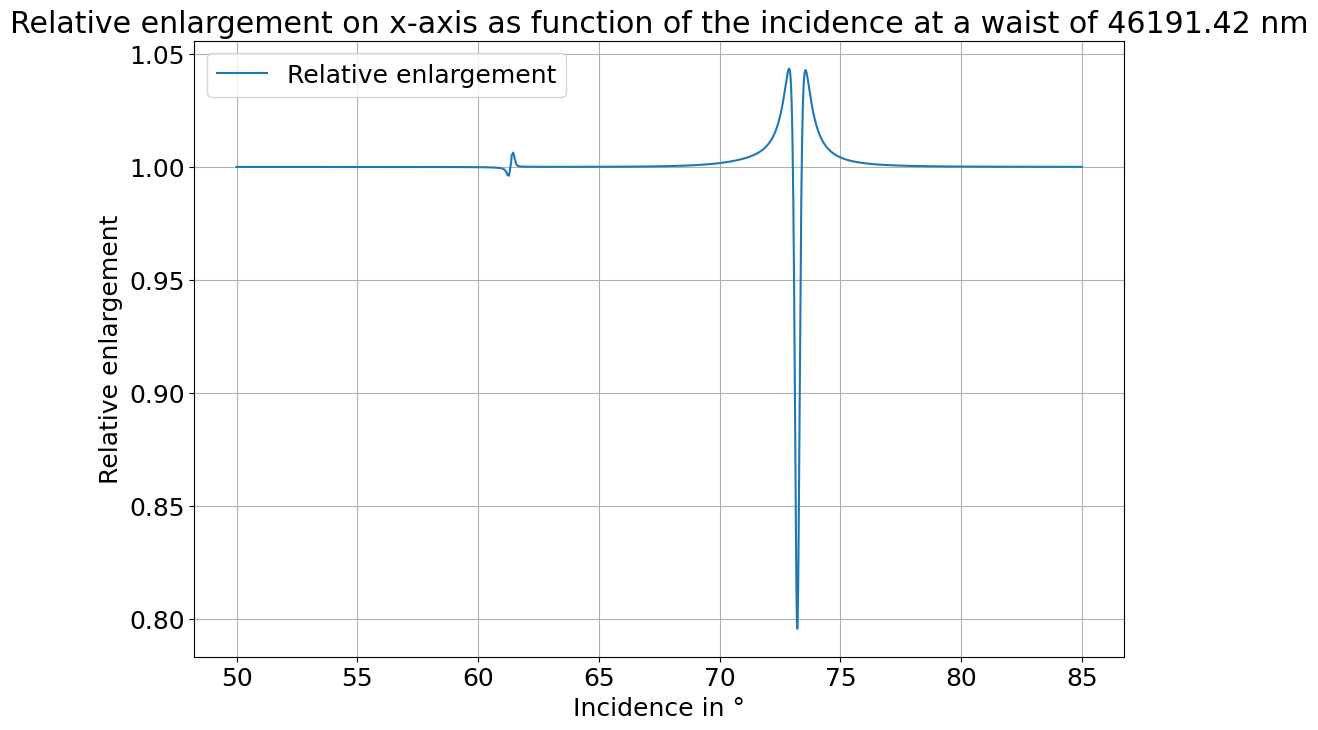

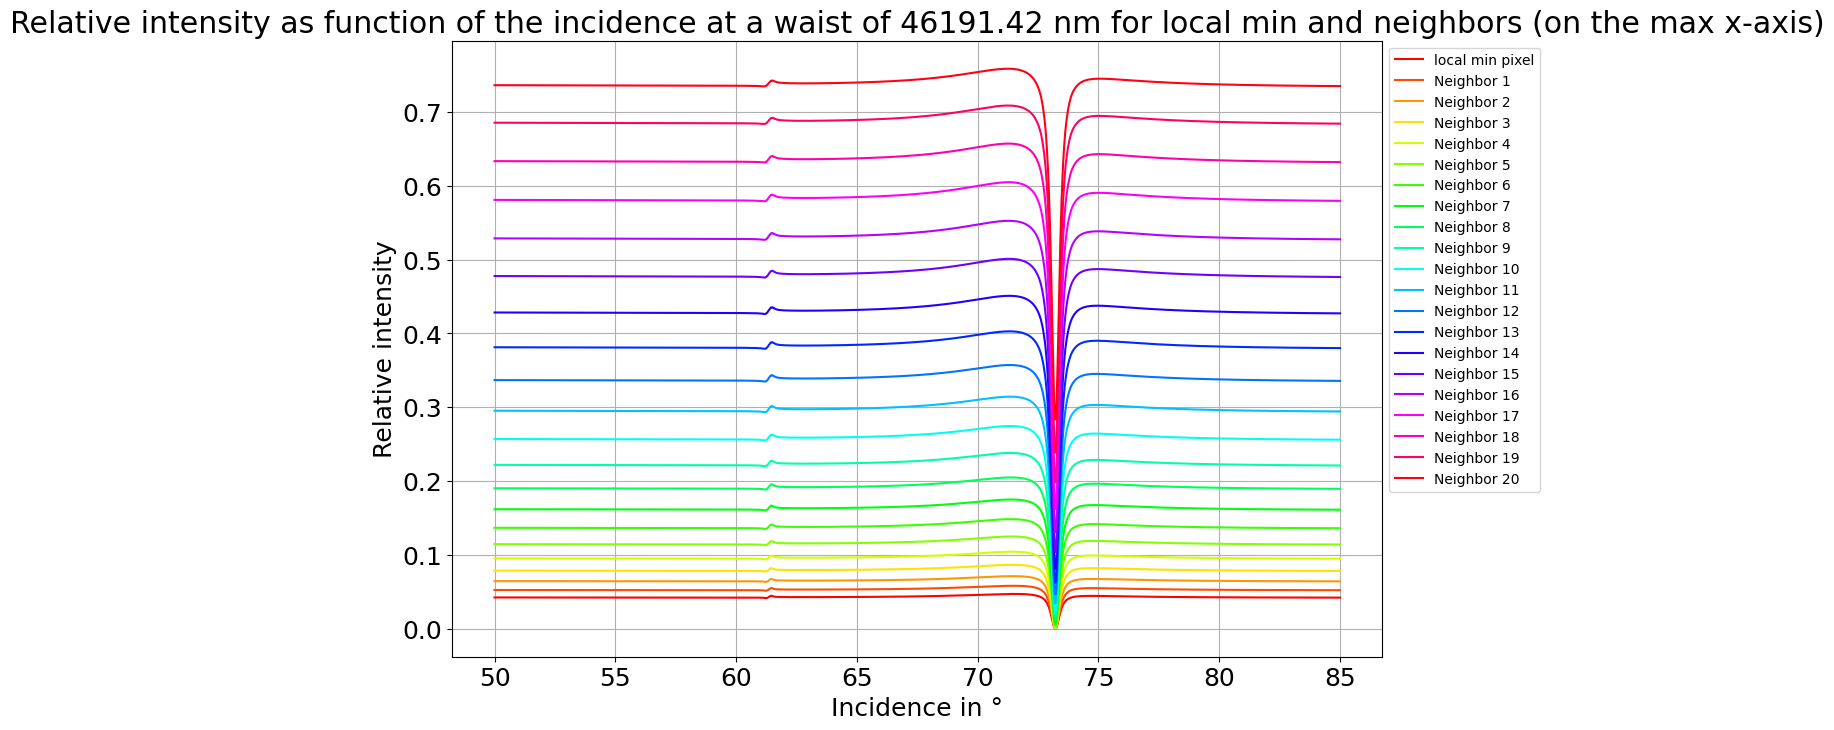

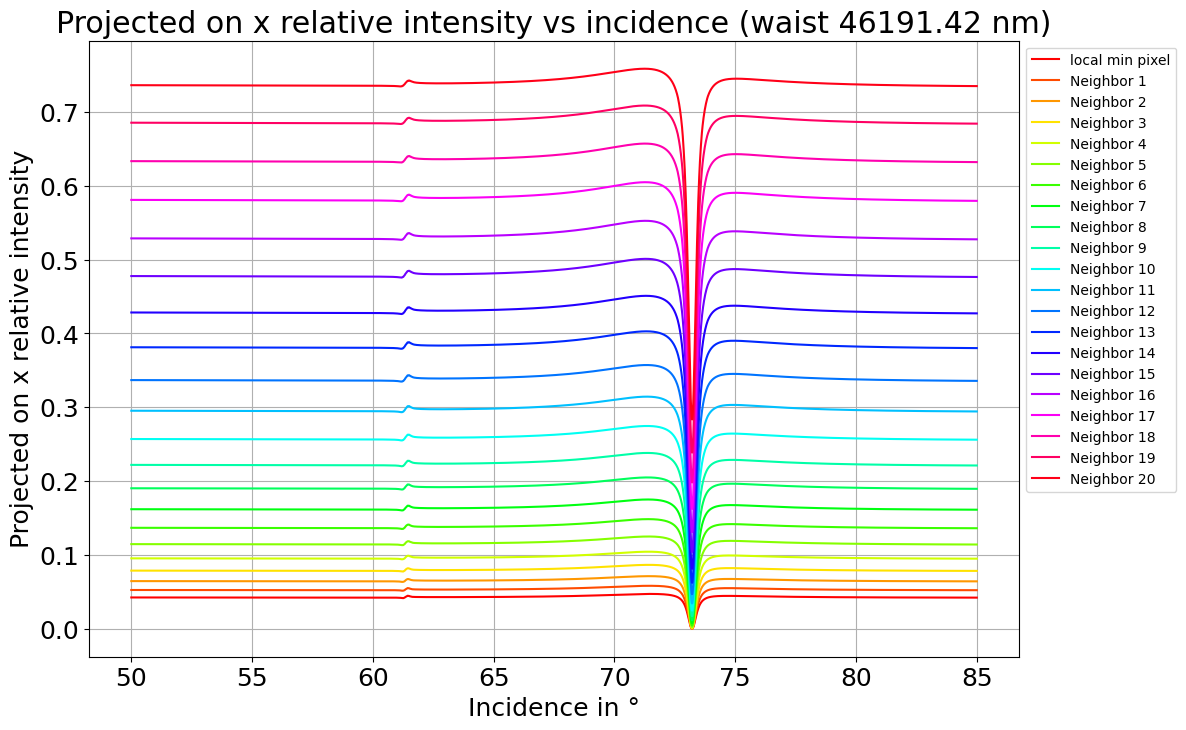

In [13]:
plt.figure(figsize=(12,8))
plt.plot(inc_range, np.array(ELx_NL), label="Relative enlargement")
plt.title(f"Relative enlargement on x-axis as function of the incidence at a waist of {w} nm")
plt.xlabel("Incidence in °")
plt.ylabel("Relative enlargement")
plt.grid()
plt.legend();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/x_rel_enlargement_with_NL.{file_ext}", bbox_inches="tight")

# where to look for the best neighbors (we are interested in  the dip area)
inc_dip_low_lim = 73.1
inc_dip_high_lim = 73.7

line_label=[f"Neighbor {i}" for i in range(0,num_neighbors+1)]
line_label[0]="local min pixel"
plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_REL_min_NL[:,i], color=colors(i), label=line_label[i])
plt.title(f"Relative intensity as function of the incidence at a waist of {w} nm for local min and neighbors (on the max x-axis)")
plt.xlabel("Incidence in °")
plt.ylabel("Relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/rel_intensity_around_local_min_with_NL.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_REL_min_NL[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_REL_min_NL[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index_NL=np.argmax(max_min_dif)
print(f"The best relative intensity observable is for {line_label[best_index_NL]} with max - min = {max_min_dif[best_index_NL]}.")

plt.figure(figsize=(12,8))
colors = plt.get_cmap("hsv", num_neighbors+1)
for i in range(0,num_neighbors+1):
    plt.plot(inc_range,I_PROJ_REL_min_NL[:,i], color=colors(i), label=line_label[i])
plt.title(f"Projected on x relative intensity vs incidence (waist {w} nm)")
plt.xlabel("Incidence in °")
plt.ylabel("Projected on x relative intensity")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10);
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/projected_rel_intensity_around_local_min_with_NL.{file_ext}", bbox_inches="tight")
max_min_dif=np.max(I_PROJ_REL_min_NL[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)-np.min(I_PROJ_REL_min_NL[(inc_range>inc_dip_low_lim)&(inc_range<inc_dip_high_lim)], axis=0)
best_index_NL=np.argmax(max_min_dif)
print(f"The best ptojected relative intensity observable is for {line_label[best_index_NL]} with max - min = {max_min_dif[best_index_NL]}.")


In [14]:
num_best_neighbor_NL = best_index_NL

Plot reflectance vs observable

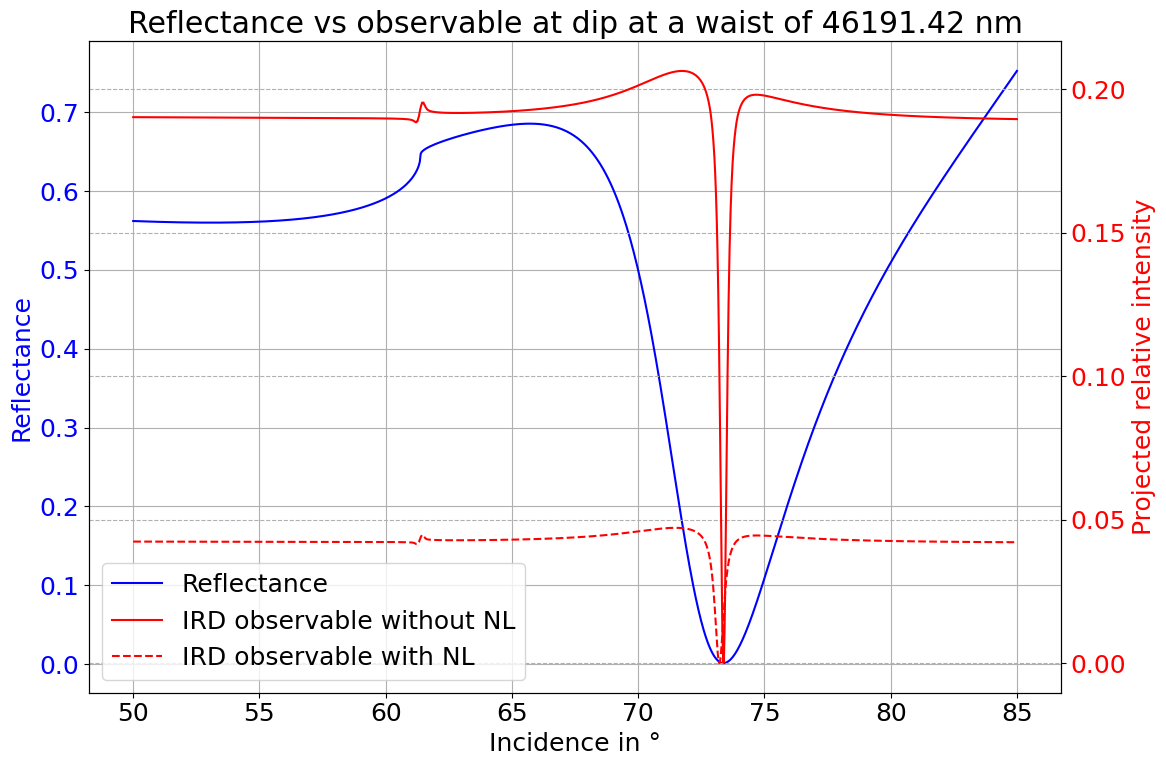

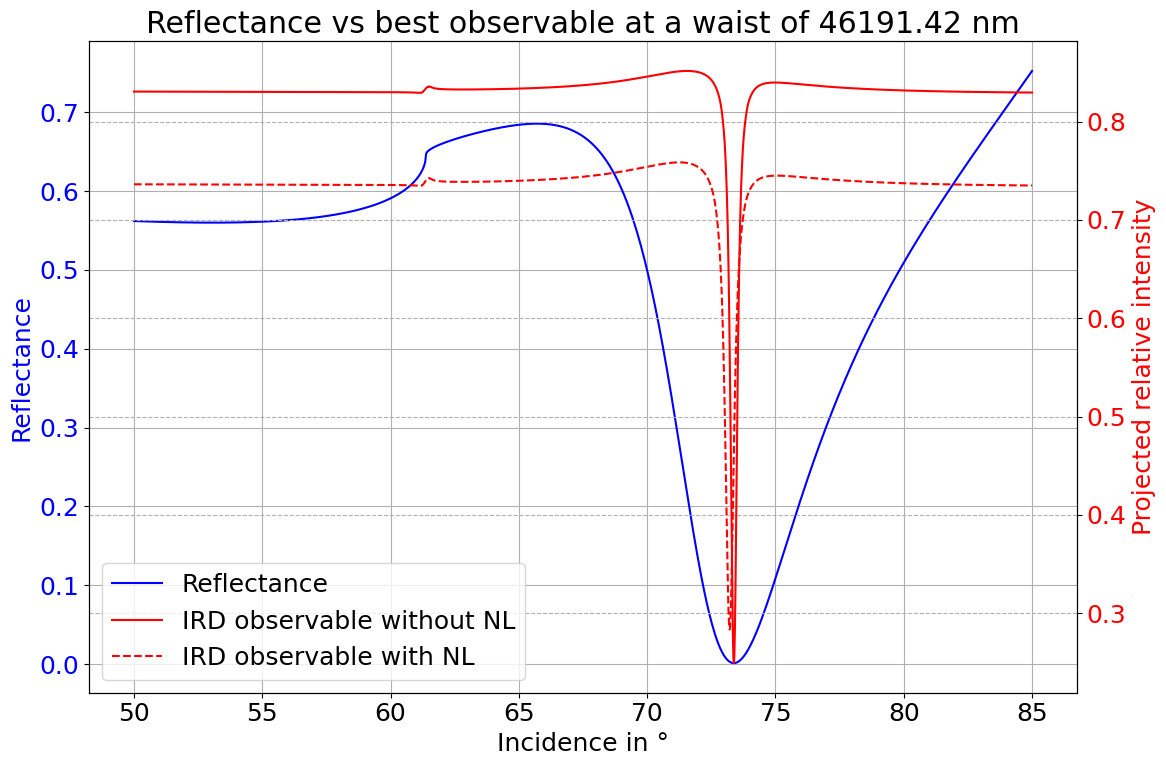

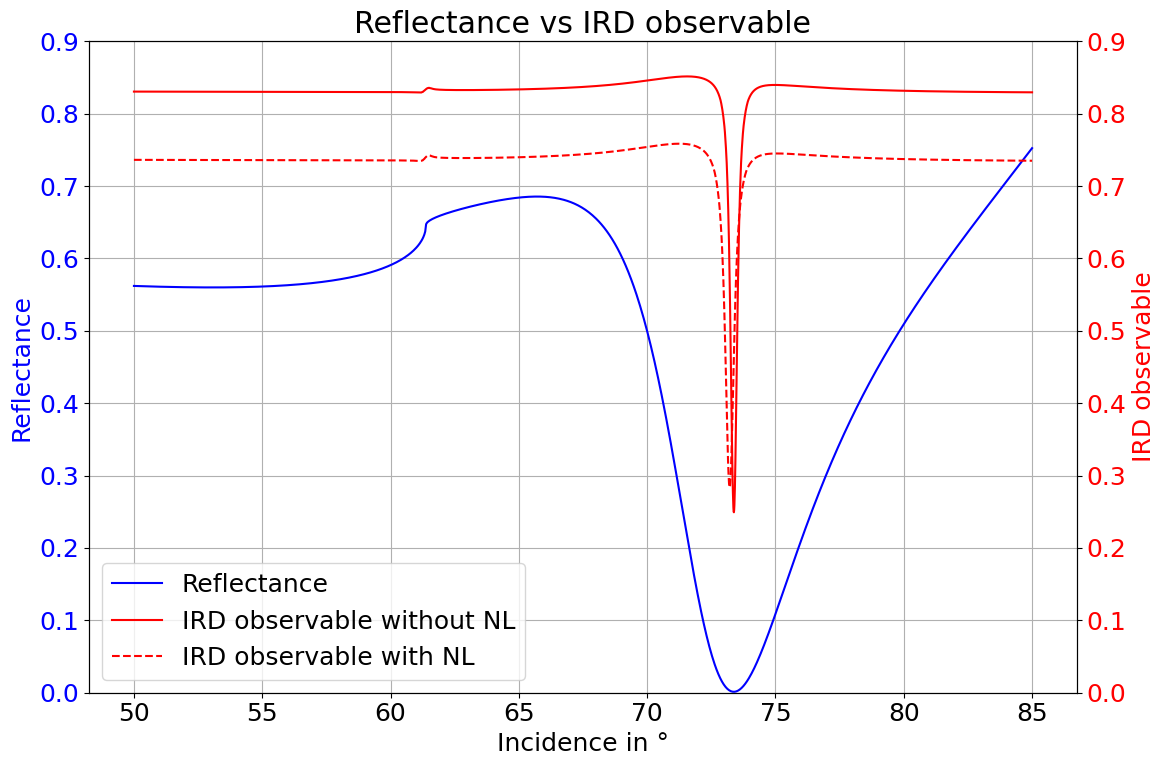

In [15]:
angle, r_plot, t_plot, R_plot, T_plot = PM.angular(structure, wavelength,1, 50, 85,1000)
# plotting of the angular reflectivity
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue", label="Reflectance")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs observable at dip at a waist of {w} nm")
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,0], color="red", label="IRD observable without NL")
ax2.plot(inc_range, I_PROJ_REL_min_NL[:,0], color="red", linestyle='--', label="IRD observable with NL")
ax2.set_ylabel("Projected relative intensity", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.grid(linestyle='--')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_local_min_with_NL.{file_ext}", bbox_inches="tight")


fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue", label="Reflectance")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs best observable at a waist of {w} nm")
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,best_index], color="red", label="IRD observable without NL")
ax2.plot(inc_range, I_PROJ_REL_min_NL[:,best_index_NL], color="red", linestyle='--', label="IRD observable with NL")
ax2.set_ylabel("Projected relative intensity", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.grid(linestyle='--')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_best_with_NL.{file_ext}", bbox_inches="tight")
        
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue", label="Reflectance")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs IRD observable")
ax1.set_ylim(0,0.9)
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,best_index], color="red",label="IRD observable without NL")
ax2.plot(inc_range, I_PROJ_REL_min_NL[:,best_index_NL], color="red", linestyle='--', label="IRD observable with NL")
ax2.set_ylabel("IRD observable", color="red")
ax2.tick_params(axis='y', labelcolor="red")
# ax2.grid(linestyle='--')
ax2.set_ylim(0,0.9)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
plt.legend(lines_1 + lines_2, labels_1 + labels_2, loc='best')
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_best_simplified_with_NL.{file_ext}", bbox_inches="tight")

Plot reflectance vs observable without NL

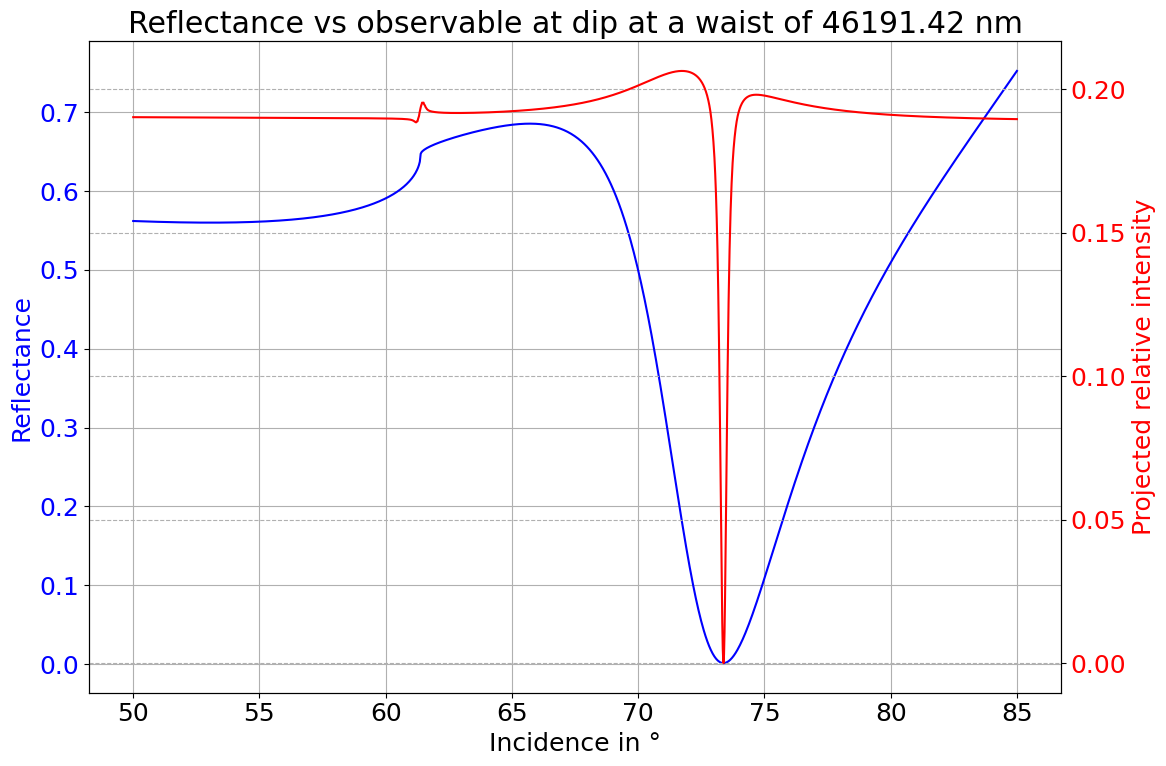

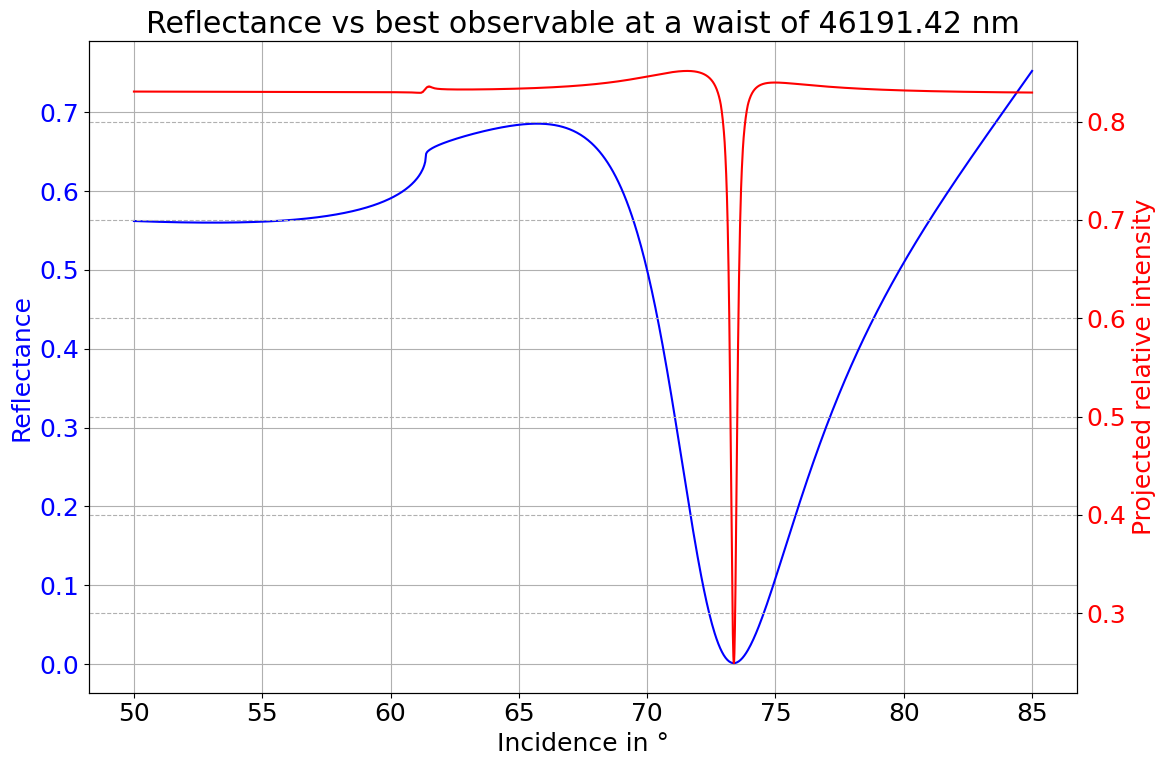

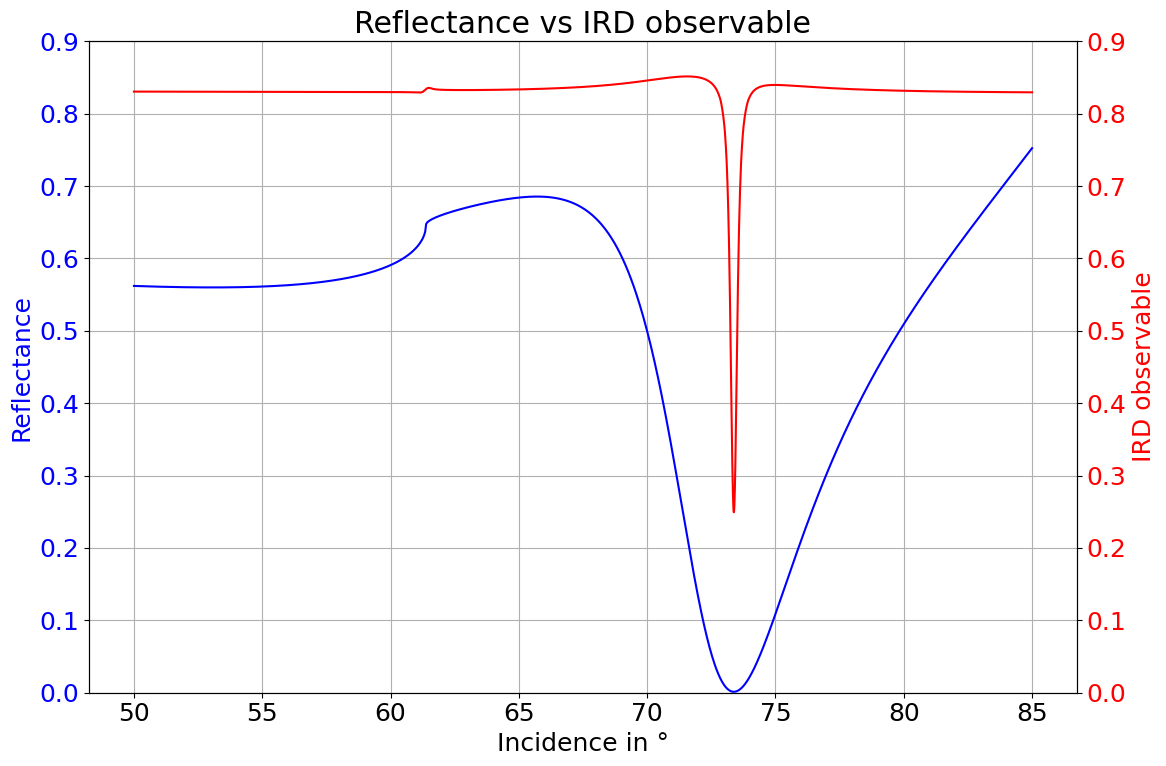

In [16]:
angle, r_plot, t_plot, R_plot, T_plot = PM.angular(structure, wavelength,1, 50, 85,1000)
# plotting of the angular reflectivity
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs observable at dip at a waist of {w} nm")
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,0], color="red")
ax2.set_ylabel("Projected relative intensity", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.grid(linestyle='--')
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_local_min.{file_ext}", bbox_inches="tight")


fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs best observable at a waist of {w} nm")
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,best_index], color="red")
ax2.set_ylabel("Projected relative intensity", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.grid(linestyle='--')
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_best.{file_ext}", bbox_inches="tight")
        
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"Reflectance vs IRD observable")
ax1.set_ylim(0,0.9)
ax1.grid()
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(inc_range, I_PROJ_REL_min[:,best_index], color="red",label="IRD observable")
ax2.set_ylabel("IRD observable", color="red")
ax2.tick_params(axis='y', labelcolor="red")
# ax2.grid(linestyle='--')
ax2.set_ylim(0,0.9)
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_vs_projected_rel_intensity_at_best_simplified.{file_ext}", bbox_inches="tight")

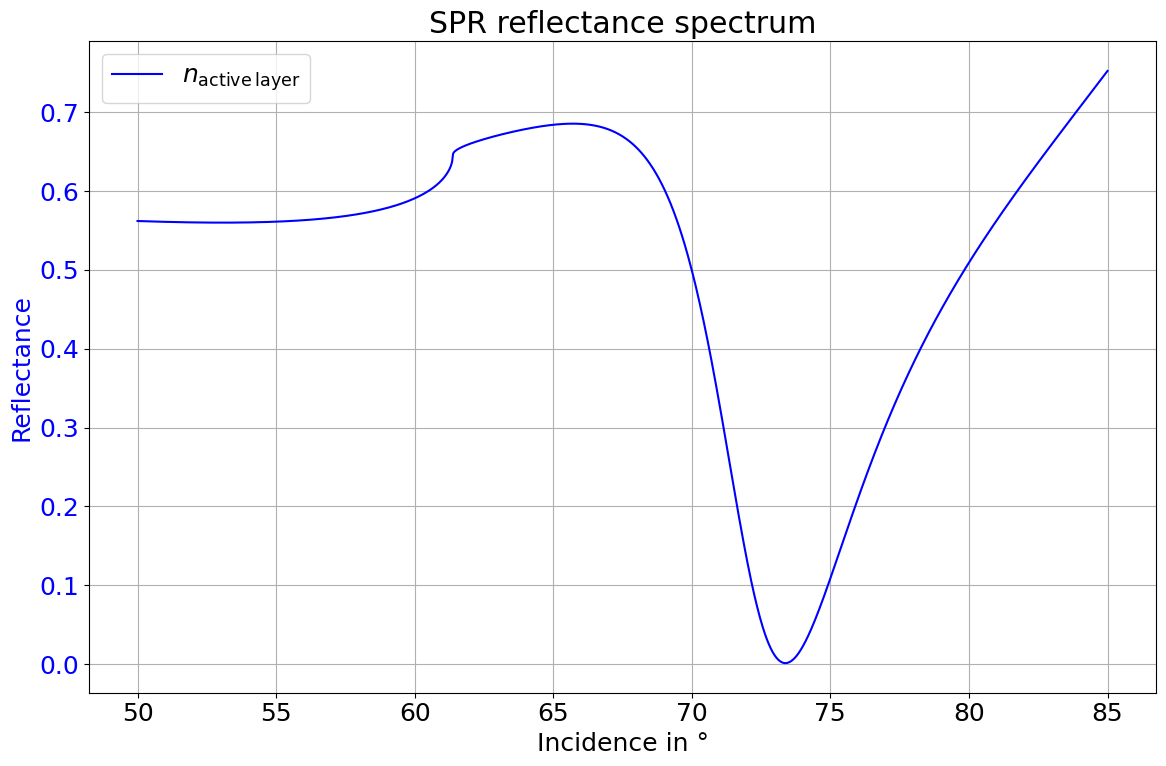

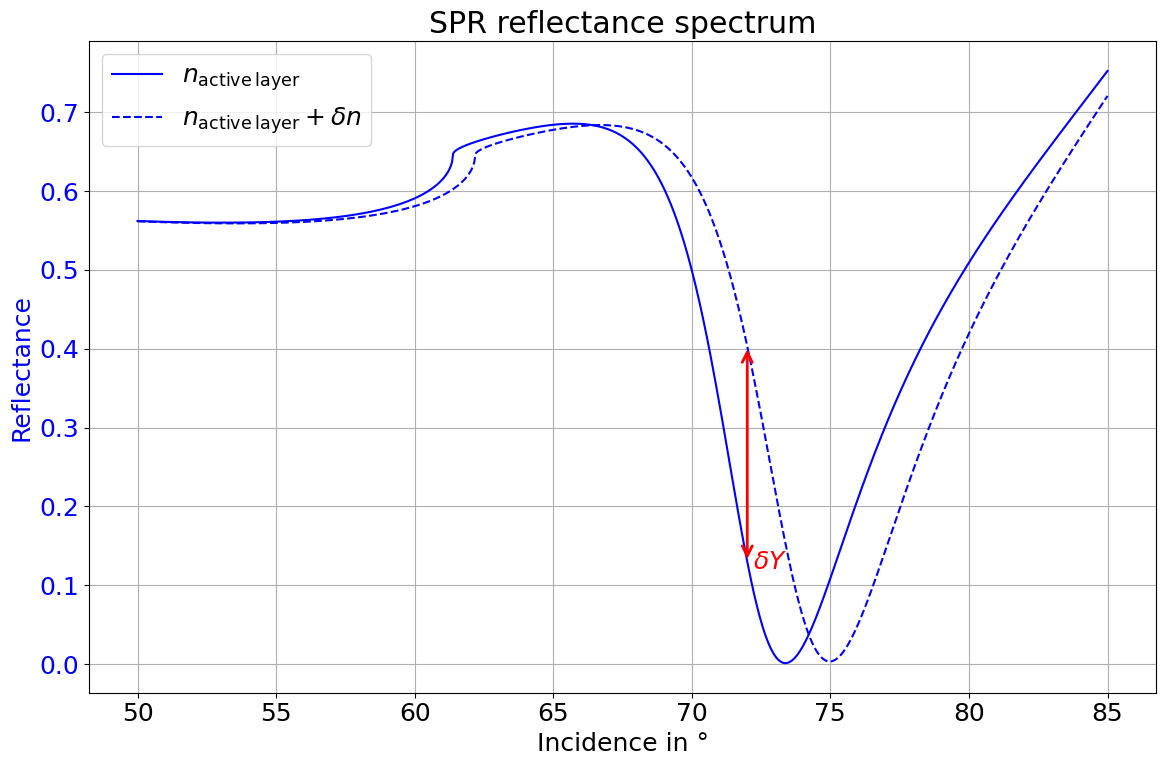

In [17]:
mat_var = ["BK7",Cr,Au,(1.33+0.01)**2]
structure_var = PM.Structure(mat_var, stack, thickness, verbose=False)

angle, r_plot, t_plot, R_plot, T_plot = PM.angular(structure, wavelength,1, 50, 85,1000)
angle_var, r_plot_var, t_plot_var, R_plot_var, T_plot_var = PM.angular(structure_var, wavelength,1, 50, 85,1000)
# plotting of the angular reflectivity
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue", label=r"$n_{\rm{active\:layer}}$")
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"SPR reflectance spectrum")
ax1.grid()
plt.legend();
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_SPR_illustration_1.{file_ext}", bbox_inches="tight")
        
# plotting of the angular reflectivity
fig, ax1 = plt.subplots(figsize=(12,8))
ax1.plot(angle, R_plot, color="blue", label=r"$n_{\rm{active\:layer}}$")
ax1.plot(angle, R_plot_var, "--",color="blue", label=r"$n_{\rm{active\:layer}}+\delta n$")
idx = np.argmin(np.abs(angle - 72))
x_val = angle[idx]
y1_val = R_plot[idx]
y2_val = R_plot_var[idx]
ax1.annotate('', xy=(x_val, y2_val), xytext=(x_val, y1_val),arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(x_val + 0.2,y1_val,r'$\delta Y$', color='red', va='center')
ax1.set_xlabel("Incidence in °")
ax1.set_ylabel("Reflectance", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_title(f"SPR reflectance spectrum")
ax1.grid()
plt.legend();
fig.tight_layout();  # otherwise the right y-label is slightly clipped
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/R_SPR_illustration_2.{file_ext}", bbox_inches="tight")


### Sensitivity with NL

In [18]:
Cr = PM.Material(["main", "Cr", "Rakic-BB"], specialType="RII")
Au_NL = NL.NLMaterial(calc_gold_nl_param_w_2nd_viscosity)
h_Au = 47
mat_NL_1 = ["BK7",Cr,Au_NL,1.33**2]  # list with all the materials needed, BK7 taken from PM .json because the one in RII don't match the wavelength, and 1.33**2 is for water
stack = [0, 1, 2, 3]  # stacking order of the materials in the  multilayered structure
thickness = [4000, 2, h_Au, 1000]  # thickness of each layer
structure_NL_1 = NL.NLStructure(mat_NL_1, stack, thickness, verbose=False)

n_variation = 0.001
mat_NL_2 = ["BK7",Cr,Au_NL,(1.33+n_variation)**2]
structure_NL_2 = NL.NLStructure(mat_NL_2, stack, thickness, verbose=False)

def process_one_inc(inc):
    kz = ((n2 * k0) ** 2 - A**2 - B**2) ** 0.5
    theta = np.arcsin(np.sqrt((A * np.cos(np.deg2rad(inc)) + kz * np.sin(np.deg2rad(inc))) ** 2 + B**2) / (n2 * k0))  # array with the incidence angle for all incident plane wave

    cr = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    cr2 = np.zeros((2 * N + 1, 2 * N + 1), dtype=complex)
    # determination of the reflection coefficients for each plane wave
    for i in range(len(a)):
        for j in range(len(b)):
            r, t, R, T = NL.NLcoefficient(structure_NL_1, wavelength, theta[i, j], 1)
            r2, t2, R2, T2 = NL.NLcoefficient(structure_NL_2, wavelength, theta[i, j], 1)
            cr[i, j] = r
            cr2[i, j] = r2
    cr1D = np.abs(cr[N, :])**2
    cr21D = np.abs(cr2[N, :])**2
    s_base = (cr21D[N] - cr1D[N]) / n_variation

    # ------- base structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el1 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I1 = (np.abs(U1i)**2)[::-1, ::-1]
    I1_rel = I1 / np.max(I1)
    if index_max_y < N:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y - num_best_neighbor_NL]
    else:
        I_rel_min_1 = I1_rel[index_max_x, index_loc_min_y + num_best_neighbor_NL]

    I_proj1 = np.sum(I1, axis=0)
    I_proj1_rel = I_proj1 / np.max(I_proj1)
    if ind_proj_max < N:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min - num_best_neighbor_NL]
    else:
        I_proj_rel_min_1 = I_proj1_rel[ind_proj_loc_min + num_best_neighbor_NL]

    # ------- modified structure -------
    U1 = my_mod.gauss2D(X, Y, wx, wy, x0, y0, alpha0, beta0)
    U1k = fftshift(fftshift(fft2(U1), axes=0), axes=1)
    U1ki = cr2 * U1k
    U1i = ifft2(U1ki)

    bxU1 = trapezoid(trapezoid(X * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    byU1 = trapezoid(trapezoid(Y * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y)
    bxU1i = trapezoid(trapezoid(X * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)
    byU1i = trapezoid(trapezoid(Y * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)

    decx = bxU1i - bxU1
    decy = byU1i - byU1
    el2 = (trapezoid(trapezoid(((X - decx)**2) * np.abs(U1i)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1i)**2, x, axis=1), y)) / (trapezoid(trapezoid((X**2) * np.abs(U1)**2, x, axis=1), y) / trapezoid(trapezoid(np.abs(U1)**2, x, axis=1), y))

    I2 = (np.abs(U1i)**2)[::-1, ::-1]
    I2_rel = I2 / np.max(I2)
    if index_max_y < N:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y - num_best_neighbor_NL]
    else:
        I_rel_min_2 = I2_rel[index_max_x, index_loc_min_y + num_best_neighbor_NL]

    I_proj2 = np.sum(I2, axis=0)
    I_proj2_rel = I_proj2 / np.max(I_proj2)
    if ind_proj_max < N:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min - num_best_neighbor_NL]
    else:
        I_proj_rel_min_2 = I_proj2_rel[ind_proj_loc_min + num_best_neighbor_NL]

    s_enlarg = (el2 - el1) / n_variation
    s_irel = (I_rel_min_2 - I_rel_min_1) / n_variation
    s_iproj = (I_proj_rel_min_2 - I_proj_rel_min_1) / n_variation

    return s_base, s_enlarg, s_irel, s_iproj


inc_range2 = np.linspace(72.4,74.4, int((74.4-72.4)/0.01)+1)

S_BASE = []
S_ENLARG = []
S_I_REL_MIN = []
S_I_PROJ_REL_MIN = []

results = Parallel(n_jobs=n_jobs)(
    delayed(process_one_inc)(inc) for inc in tqdm(inc_range2, desc="Scan of all the incidences")
)

for s_base, s_enlarg, s_irel, s_iproj in results:
    S_BASE.append(s_base)
    S_ENLARG.append(s_enlarg)
    S_I_REL_MIN.append(s_irel)
    S_I_PROJ_REL_MIN.append(s_iproj)

Scan of all the incidences: 100%|██████████| 201/201 [03:57<00:00,  1.18s/it]


Maximum sensitivity from reflectance is 17.51 at 72.40°.
Maximum sensitivity from relative enlargement on x is 184.26 (952.33% improvement) at 73.19°.
Maximum sensitivity relative light intensity at 20 pixels from the local minimum at 73.21° is 213.47 (1119.16% improvement) at 73.15°.
Maximum sensitivity from relative light intensity projected on x-axis at 20 pixels from the local minimum at 73.21° is 213.47 (1119.17% improvement) at 73.15°.


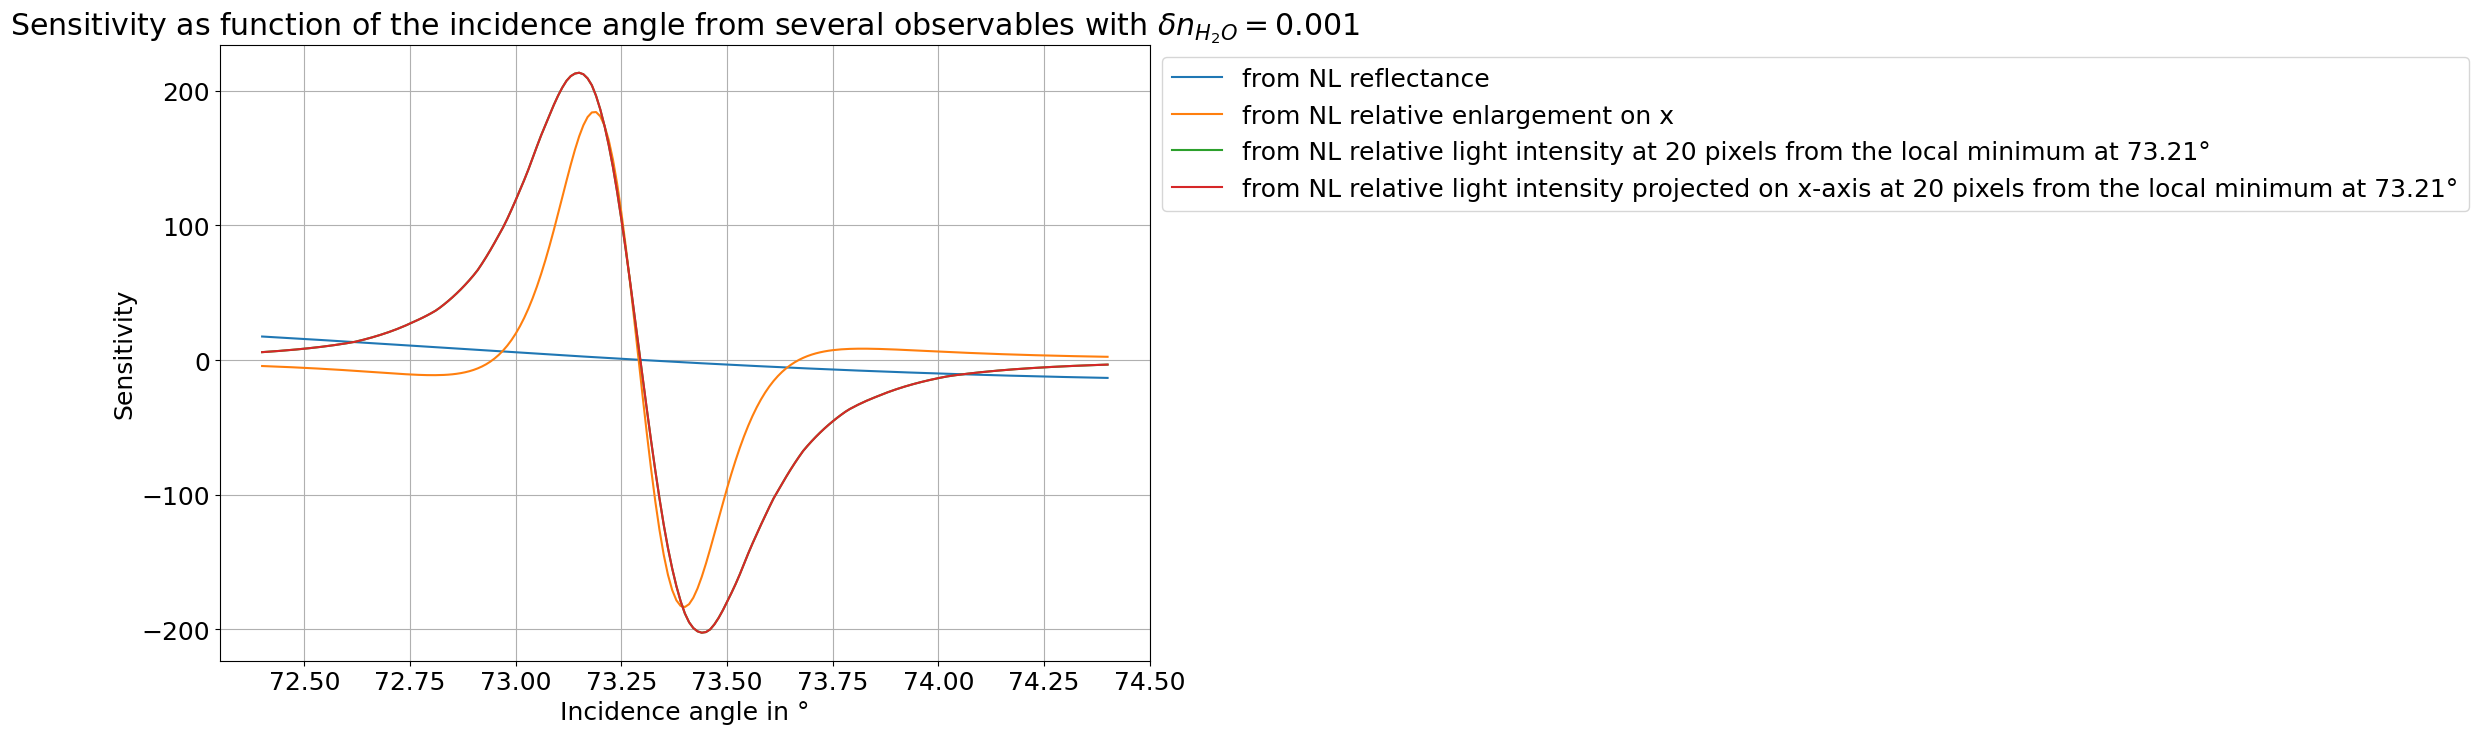

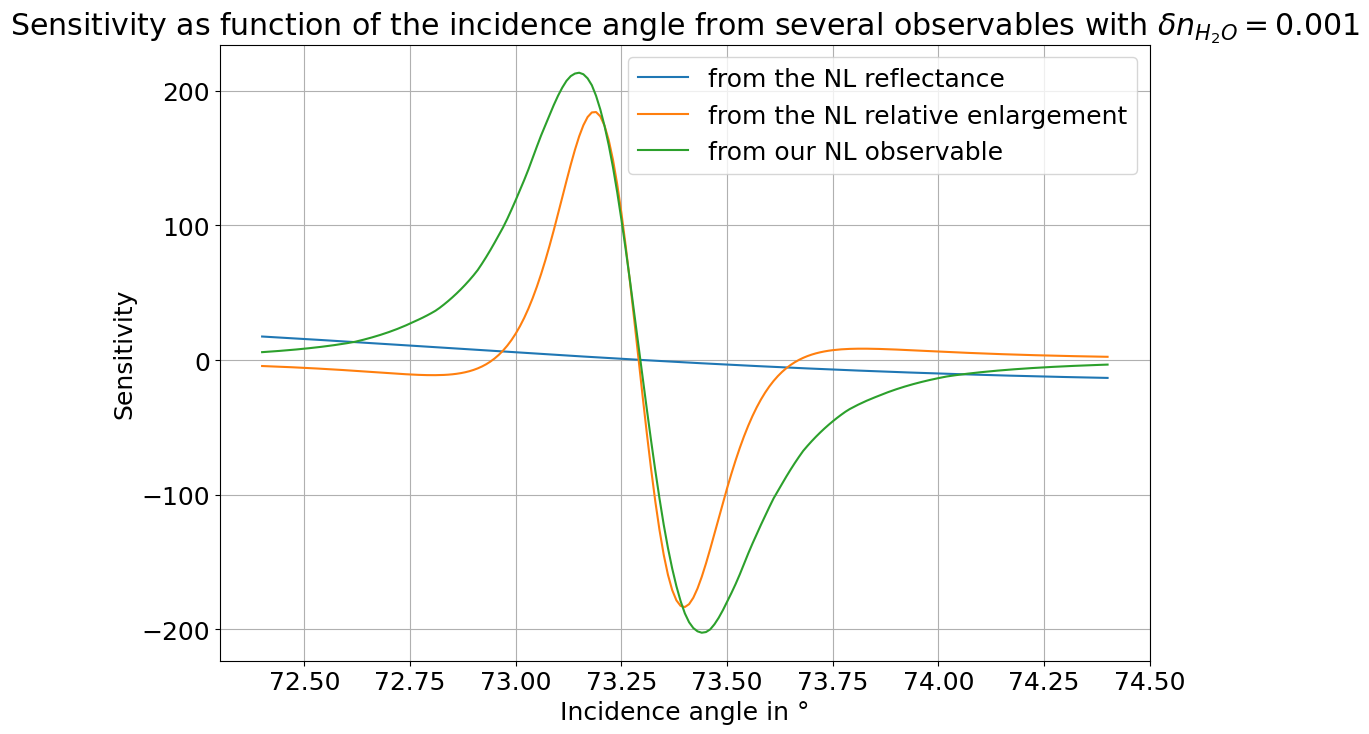

In [20]:
plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="from NL reflectance")
plt.plot(inc_range2, S_ENLARG, label="from NL relative enlargement on x")
plt.plot(inc_range2, S_I_REL_MIN, label=f"from NL relative light intensity at {best_index_NL} pixels from the local minimum at 73.21°")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"from NL relative light intensity projected on x-axis at {best_index_NL} pixels from the local minimum at 73.21°")
plt.title(fr"Sensitivity as function of the incidence angle from several observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/sensitivity_NL.{file_ext}", bbox_inches="tight")

plt.figure(figsize=(12,8))
plt.plot(inc_range2, S_BASE, label="from the NL reflectance")
plt.plot(inc_range2, S_ENLARG, label="from the NL relative enlargement")
plt.plot(inc_range2, S_I_PROJ_REL_MIN, label=f"from our NL observable")
plt.title(fr"Sensitivity as function of the incidence angle from several observables with $\delta n_{{H_2O}} = ${n_variation}")
plt.xlabel("Incidence angle in °")
plt.ylabel("Sensitivity")
plt.legend(loc="best")
plt.grid();
if SAVE_MODE:
    for file_ext in save_formats:
        plt.savefig(f"Plots/{file_ext}/observables_extra_plots/sensitivity_simple_NL.{file_ext}", bbox_inches="tight")

print(f"Maximum sensitivity from reflectance is {np.max(np.abs(S_BASE)):.2f} at {inc_range2[np.argmax(np.abs(S_BASE))]:.2f}°.")
print(f"Maximum sensitivity from relative enlargement on x is {np.max(np.abs(S_ENLARG)):.2f} ({(np.max(np.abs(S_ENLARG))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_ENLARG))]:.2f}°.")
print(f"Maximum sensitivity relative light intensity at {best_index_NL} pixels from the local minimum at 73.21° is {np.max(np.abs(S_I_REL_MIN)):.2f} ({(np.max(np.abs(S_I_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_REL_MIN))]:.2f}°.")
print(f"Maximum sensitivity from relative light intensity projected on x-axis at {best_index_NL} pixels from the local minimum at 73.21° is {np.max(np.abs(S_I_PROJ_REL_MIN)):.2f} ({(np.max(np.abs(S_I_PROJ_REL_MIN))/np.max(np.abs(S_BASE))-1)*100:.2f}% improvement) at {inc_range2[np.argmax(np.abs(S_I_PROJ_REL_MIN))]:.2f}°.")